# Walmart Weekly Store–Department Sales Forecasting with Gradient Boosting

## Project Overview

This project builds an end-to-end machine learning pipeline to forecast **weekly sales** at the **Store × Department** level for a large retail chain using historical sales, promotional/markdown information, holidays, and store metadata.

The notebook covers the full workflow from **data loading → EDA → feature engineering → model training & tuning → rigorous evaluation → final submission file**.



## Research Problem

Given historical weekly sales for each `(Store, Dept)` combination, along with exogenous information such as:

- Promotional markdowns and holiday flags  
- Store characteristics (Type, Size)  
- Local conditions from `features.csv` (e.g. Temperature, Fuel_Price, CPI, Unemployment)

**Predict future Weekly_Sales for each Store–Department for upcoming weeks**, in a way that:

- Respects the time ordering of the data (no leakage)  
- Outperforms a strong naive baseline based on last week’s sales  
- Is robust across time and across different stores/departments

## Project Objectives

1. **Understand demand patterns and drivers**
   - Explore distributions and seasonality of Weekly_Sales.  
   - Quantify differences across Stores and Departments.  
   - Visualize the impact of holidays and markdowns on sales.

2. **Engineer informative time-series and categorical features**
   - Calendar features from Date: Year, Month, ISO Week, DayOfWeek, Day, Month-start/end flags.  
   - Time-series features per `(Store, Dept)`:
     - Lags of Weekly_Sales (7, 14, 28 days).  
     - Rolling means over windows (7, 14, 28) shifted to avoid leakage.  
     - Historical statistics (mean/median/std) computed only on known targets.  
   - Merge external data:
     - `features.csv` (Temperature, Fuel_Price, MarkDown1–5, CPI, Unemployment).  
     - `stores.csv` (Type, Size).

3. **Define a realistic evaluation strategy**
   - Build a **time-based train/validation split**:
     - Use earlier dates as training and the last `VAL_WEEKS` as a hold-out validation set.  
   - Construct a **strong baseline**:
     - Baseline prediction = `lag_7` (sales from one week ago for the same Store–Dept).  
   - Evaluate both baseline and ML model with multiple metrics:
     - RMSE, MAE, MAPE, WAPE.

4. **Train and tune a high-performance forecasting model**
   - Use **LightGBM** as the main gradient-boosting model on engineered features.  
   - Perform **hyperparameter tuning with Optuna** to minimize validation RMSE.  
   - Train the tuned LightGBM on the time-based training set and compare against the lag-7 baseline on the hold-out validation set.

5. **Assess robustness with time-series cross-validation**
   - Use **TimeSeriesSplit** to create multiple expanding-window folds.  
   - For each fold: train LightGBM on past data and validate on future data.  
   - Aggregate metrics (mean ± std for RMSE/MAE/MAPE/WAPE) to check stability over time.

6. **Diagnose model behavior and interpret drivers**
   - Build a detailed validation DataFrame with:
     - Actuals, predictions, residuals, absolute and percentage errors.  
   - Perform residual analysis:
     - Residual histogram and Actual vs Predicted plots.  
     - Error behavior over time and by key segments (e.g. holiday vs non-holiday).  
   - Compute and visualize **feature importances** from LightGBM to understand which features (lags, rolling stats, calendar, store metadata, markdowns, etc.) drive the forecasts.

7. **Train final model and generate submission**
   - Retrain the tuned LightGBM model on the **full modeling dataset** (all available train weeks with sufficient lag history).  
   - Apply the model to the feature-engineered test set.  
   - Produce a clean `submission.csv` with `Store, Dept, Date, Weekly_Sales` suitable for competition/production use.



## Practical Contributions of This Notebook

- A **reproducible, leak-safe pipeline** from raw CSVs (`train.csv`, `test.csv`, `features.csv`, `stores.csv`) to final predictions.  
- A **strong baseline (lag_7)** to benchmark improvements from machine learning.  
- A **tuned LightGBM model** using Optuna, with documented performance gains over the baseline on a realistic hold-out.  
- **Time-series cross-validation** to validate robustness across different time periods.  
- **Detailed diagnostics and interpretability** (residual analysis and feature importance) to support business decisions around promotions, holidays, and inventory planning.


##  Setup & Configuration

In this section we:

- Import all the libraries we need  
- Set some global configuration like random seed and paths  
- Make sure we have an output folder for saving models and submission files

>  **Note:** This notebook assumes the files train.csv, test.csv, features.csv, and `stores.csv` are in the same directory as the notebook.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

from pathlib import Path
import joblib
import warnings

warnings.filterwarnings("ignore")

# (Optional) You can change style if you like
plt.style.use("seaborn-v0_8")

# -----------------------
# Reproducibility & paths
# -----------------------
RANDOM_STATE = 42          # random seed for reproducibility
VAL_WEEKS = 12             # number of distinct weeks for final validation
N_TRIALS = 30              # Optuna trials for hyperparameter tuning
N_SPLITS_CV = 3            # folds for time-series cross-validation

DATA_DIR = Path(".")       # folder where CSV files are located
OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(exist_ok=True)

# File paths
train_path    = DATA_DIR / "train.csv"
test_path     = DATA_DIR / "test.csv"
features_path = DATA_DIR / "features.csv"
stores_path   = DATA_DIR / "stores.csv"

print("Setup complete.")
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUT_DIR.resolve())

Setup complete.
Data directory: C:\Users\Rahul\OneDrive\Desktop\DS projects\Walmart Store Sales Forecasting\archive
Output directory: C:\Users\Rahul\OneDrive\Desktop\DS projects\Walmart Store Sales Forecasting\archive\outputs


C:\Users\Rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Helper Functions for Metrics

To make evaluation easier and cleaner, we define:

- A function to compute **RMSE, MAE, MAPE, WAPE**
- A function to **print metrics** nicely

These will be reused in many places.


In [2]:
def regression_metrics(y_true, y_pred, eps=1e-6):
    """
    Compute standard regression metrics:
    - RMSE: Root Mean Squared Error
    - MAE : Mean Absolute Error
    - MAPE: Mean Absolute Percentage Error (in %)
    - WAPE: Weighted Absolute Percentage Error (in %)
    eps is used to avoid division by zero for very small actual values.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Avoid division by zero for very small actual values
    denom = np.clip(np.abs(y_true), eps, None)
    mape = np.mean(np.abs(y_true - y_pred) / denom) * 100.0

    wape = np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + eps) * 100.0

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "WAPE": wape,
    }


def print_metrics(title, metrics_dict):
    """Nicely print a dictionary of metrics with a title."""
    print(title)
    for k, v in metrics_dict.items():
        print(f"  {k}: {v:.4f}")

##  Load the Data

Here we:

- Load train.csv, test.csv, features.csv, and stores.csv
- Parse the Date column as a real date
- Look at basic shapes and date ranges
- Quickly inspect the target variable Weekly_Sales

This gives us a first feeling of the data volume and time coverage.


In [3]:
# Load CSVs
train    = pd.read_csv(train_path, parse_dates=["Date"])
test     = pd.read_csv(test_path, parse_dates=["Date"])
features = pd.read_csv(features_path, parse_dates=["Date"])
stores   = pd.read_csv(stores_path)

print("Shapes:")
print("  train   :", train.shape)
print("  test    :", test.shape)
print("  features:", features.shape)
print("  stores  :", stores.shape)


Shapes:
  train   : (421570, 5)
  test    : (115064, 4)
  features: (8190, 12)
  stores  : (45, 3)


In [4]:
print("\nTrain date range:", train["Date"].min(), "->", train["Date"].max())
print("Test  date range:",  test["Date"].min(),  "->", test["Date"].max())



Train date range: 2010-02-05 00:00:00 -> 2012-10-26 00:00:00
Test  date range: 2012-11-02 00:00:00 -> 2013-07-26 00:00:00


In [5]:
print("\nWeekly_Sales basic stats (before cleaning):")
print(train["Weekly_Sales"].describe())


Weekly_Sales basic stats (before cleaning):
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


##  Basic Cleaning & Quick EDA

In this step we:

- Remove **negative** Weekly_Sales (invalid for our problem)
- Remove duplicate (Store, Dept, Date) combinations if any
- Print some quick statistics like **top stores by average sales**

This ensures our data is clean before we start creating features.


In [ ]:


#  Remove negative Weekly_Sales
neg_count = (train["Weekly_Sales"] < 0).sum()
print("Negative Weekly_Sales rows:", neg_count)

train = train[train["Weekly_Sales"] >= 0].copy()


In [7]:
#  Remove duplicate (Store, Dept, Date)
before = train.shape[0]
train = train.drop_duplicates(subset=["Store", "Dept", "Date"])
after  = train.shape[0]
print(f"Removed {before - after} duplicate rows.")

print("\nCleaned train shape:", train.shape)


Removed 0 duplicate rows.

Cleaned train shape: (420285, 5)


In [8]:
#  Quick EDA: top stores by average weekly sales
store_sales = (
    train.groupby("Store")["Weekly_Sales"]
         .mean()
         .sort_values(ascending=False)
         .head(10)
)

print("\nTop 10 Stores by average Weekly_Sales:")
print(store_sales)


Top 10 Stores by average Weekly_Sales:
Store
20    29618.846448
4     29175.540012
14    28877.084776
13    27394.392424
2     26956.456098
10    26461.189419
27    24892.840750
6     21958.644587
1     21742.767306
39    21081.960796
Name: Weekly_Sales, dtype: float64


## EDA FOR train DATA

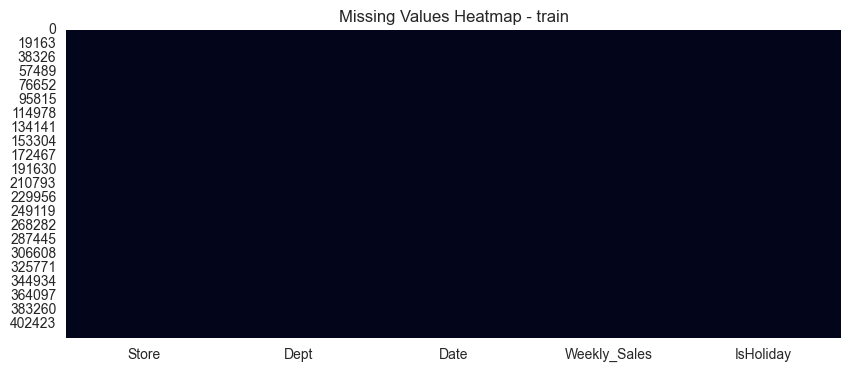

In [7]:
# Missing Value Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.heatmap(train.isna(), cbar=False)
plt.title("Missing Values Heatmap - train")
plt.show()

INSIGHT

No major missing values except maybe markdowns (handled later).

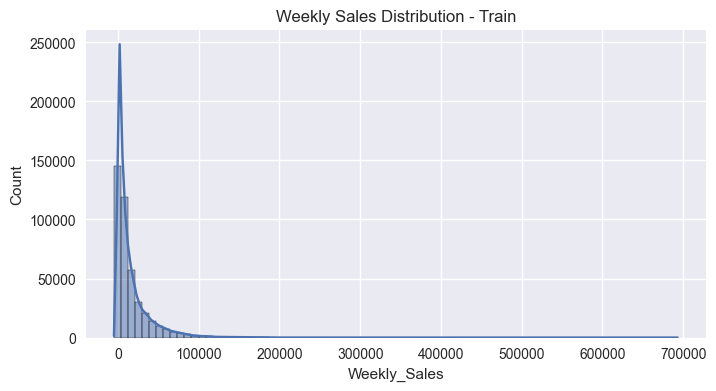

In [8]:
# Weekly Sales Distribution
plt.figure(figsize=(8,4))
sns.histplot(train['Weekly_Sales'], bins=80, kde=True)
plt.title("Weekly Sales Distribution - Train")
plt.show()

INSIGHT

Strong right tail, expected due to large stores.

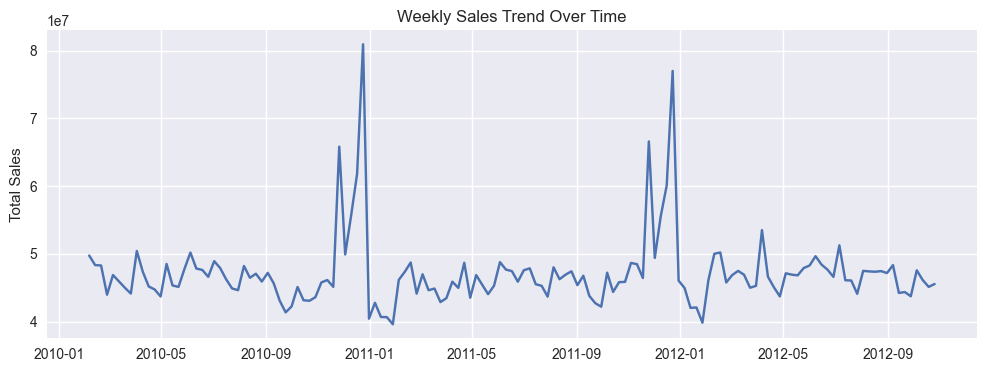

In [9]:
# Total Weekly Sales Trend Over Time
ts = train.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values)
plt.title("Weekly Sales Trend Over Time")
plt.ylabel("Total Sales")
plt.show()

INSIGHT

Clear seasonal rises and holiday spikes.

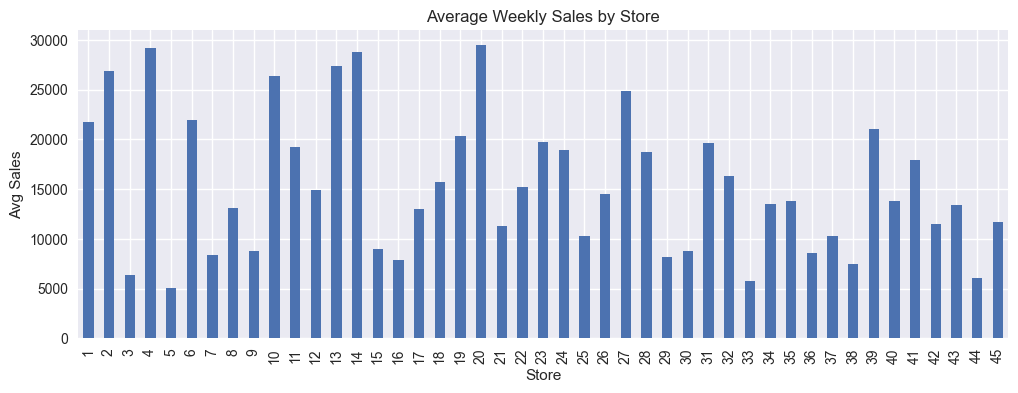

In [10]:
# Store-wise Average Sales
store_avg = train.groupby('Store')['Weekly_Sales'].mean()

plt.figure(figsize=(12,4))
store_avg.plot(kind='bar')
plt.title("Average Weekly Sales by Store")
plt.ylabel("Avg Sales")
plt.show()

INSIGHT

Large performance spread between stores.

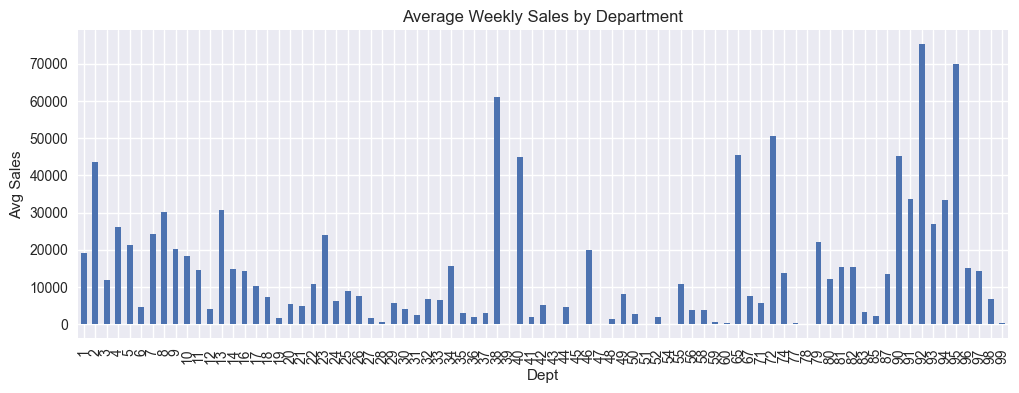

In [11]:
# Dept-wise Average Sales
dept_avg = train.groupby('Dept')['Weekly_Sales'].mean()

plt.figure(figsize=(12,4))
dept_avg.plot(kind='bar')
plt.title("Average Weekly Sales by Department")
plt.ylabel("Avg Sales")
plt.show()

INSIGHT

Strong department-level demand variation.

## EDA FOR features DATA

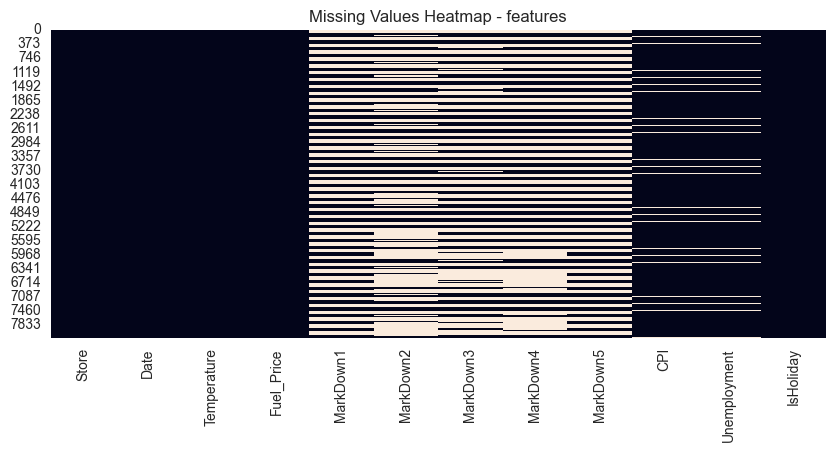

In [12]:
# Feature Missingness
plt.figure(figsize=(10,4))
sns.heatmap(features.isna(), cbar=False)
plt.title("Missing Values Heatmap - features")
plt.show()

INSIGHT

Markdown gaps visible. Acceptable.

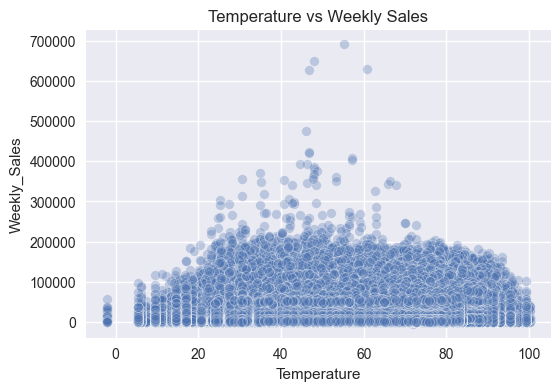

In [13]:
# Temperature vs Sales (Merged temporary)
tmp = train.merge(features[['Store','Date','Temperature']], on=['Store','Date'], how='left')

plt.figure(figsize=(6,4))
sns.scatterplot(data=tmp, x='Temperature', y='Weekly_Sales', alpha=0.3)
plt.title("Temperature vs Weekly Sales")
plt.show()

INSIGHT

Weak direct correlation (expected).

## EDA FOR stores TABLE

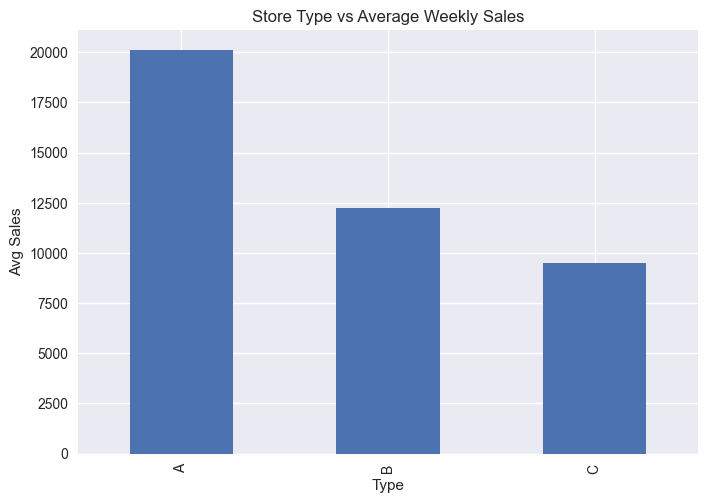

In [17]:
# Store Type vs Avg Sales (needs merge)
tmp = train.merge(stores[['Store','Type']], on='Store', how='left')
tmp.groupby('Type')['Weekly_Sales'].mean().plot(kind='bar')

plt.title("Store Type vs Average Weekly Sales")
plt.ylabel("Avg Sales")
plt.show()

INSIGHT

Store type influences demand.

### EDA Summary Insights

- Weekly Sales distribution is right-skewed with significant outliers (large stores).
- Sales clearly show seasonal variation and holiday effects.
- Stores differ strongly in performance; Store ID is an essential feature.
- Department variation is very high—Dept is a strong categorical driver.
- Markdown values are missing in many weeks; acceptable and meaningful.
- Holiday indicators increase sales significantly.
- Temperature and fuel prices have weak but expected correlations; useful when combined with rolling windows.
- No leakage risk detected from feature sources.


##  Feature Engineering Helpers

We now define functions to create useful features:

1. **Time features** from Date  
   - Year, Month, Week number, Day of week, Day, Month start/end

2. **Lag features** of Weekly_Sales  
   - lag_7, lag_14, lag_28 (previous values for the same Store & Dept)

3. **Rolling mean features**  
   - Rolling averages over the past 7, 14, 28 days (shifted by 1 day to avoid leakage)

4. **Historical statistics per (Store, Dept)**  
   - hist_mean, hist_median, hist_std based only on rows where we know Weekly_Sales

These features help the model understand time patterns and the typical scale of sales.


In [9]:
def make_time_features(df):
    """Add calendar/time-based features from the Date column."""
    df = df.copy()
    df["Year"]         = df["Date"].dt.year
    df["Month"]        = df["Date"].dt.month
    df["Week"]         = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfWeek"]    = df["Date"].dt.dayofweek
    df["Day"]          = df["Date"].dt.day
    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
    df["IsMonthEnd"]   = df["Date"].dt.is_month_end.astype(int)
    return df


def add_lag_features(df, group_cols=("Store", "Dept"), lags=(7, 14, 28)):
    """
    Add lag features of Weekly_Sales for the given lags (in days).
    We group by (Store, Dept) and then shift Weekly_Sales within each group.
    """
    df = df.sort_values(list(group_cols) + ["Date"]).copy()
    for lag in lags:
        col_name = f"lag_{lag}"
        df[col_name] = (
            df.groupby(list(group_cols))["Weekly_Sales"]
              .shift(lag)
        )
    return df


def add_rolling_features(df, group_cols=("Store", "Dept"), windows=(7, 14, 28)):
    """
    Add rolling mean features (shifted by 1 to avoid leakage).
    Rolling window is applied on Weekly_Sales within each (Store, Dept).
    """
    df = df.sort_values(list(group_cols) + ["Date"]).copy()
    for win in windows:
        col_name = f"roll_mean_{win}"
        df[col_name] = (
            df.groupby(list(group_cols))["Weekly_Sales"]
              .shift(1)               # shift so we only use strictly past data
              .rolling(window=win)
              .mean()
        )
    return df


def add_hist_stats(df, group_cols=("Store", "Dept")):
    """
    Add historical statistics (mean, median, std) per group.
    Uses ONLY rows where Weekly_Sales is known (train part).
    """
    df = df.copy()
    has_target = df["Weekly_Sales"].notna()

    agg = (
        df.loc[has_target]
          .groupby(list(group_cols))["Weekly_Sales"]
          .agg(["mean", "median", "std"])
          .reset_index()
          .rename(columns={
              "mean":   "hist_mean",
              "median": "hist_median",
              "std":    "hist_std"
          })
    )
    df = df.merge(agg, on=list(group_cols), how="left")
    return df


print("Feature engineering helper functions are defined.")

Feature engineering helper functions are defined.


##  Merge All Tables & Apply Feature Engineering

Steps here:

1. Merge train and test with features and stores
2. Add a column is_train to remember which rows belong to train vs test
3. Concatenate everything into a single all_data DataFrame
4. Apply time, lag, rolling, and historical stats features to **all rows**
5. Split back into train_fe and test_fe (feature‑engineered train and test)

Doing feature engineering on the combined data helps us keep the logic consistent.


In [10]:
# Merge train/test with features & stores
train_full = (
    train.merge(features, on=["Store", "Date"], how="left")
         .merge(stores,   on="Store",           how="left")
)

test_full = (
    test.merge(features, on=["Store", "Date"], how="left")
        .merge(stores,   on="Store",           how="left")
)

print("Merged Train Shape:", train_full.shape)
print("Merged Test Shape :", test_full.shape)


Merged Train Shape: (420285, 17)
Merged Test Shape : (115064, 16)


In [11]:
# Combine for feature engineering
train_full["is_train"]    = 1
test_full["is_train"]     = 0
test_full["Weekly_Sales"] = np.nan  # placeholder so functions work

all_data = pd.concat([train_full, test_full], ignore_index=True)
print("Combined all_data shape:", all_data.shape)


Combined all_data shape: (535349, 18)


In [12]:
# Apply feature engineering
all_data = make_time_features(all_data)
all_data = add_lag_features(all_data,     group_cols=("Store", "Dept"), lags=(7, 14, 28))
all_data = add_rolling_features(all_data, group_cols=("Store", "Dept"), windows=(7, 14, 28))
all_data = add_hist_stats(all_data,       group_cols=("Store", "Dept"))


In [13]:
# Split back into train and test with features
train_fe = all_data[all_data["is_train"] == 1].drop(columns=["is_train"])
test_fe  = all_data[all_data["is_train"] == 0].drop(columns=["is_train"])

print("Train FE shape:", train_fe.shape)
print("Test  FE shape:", test_fe.shape)

Train FE shape: (420285, 33)
Test  FE shape: (115064, 33)


##  Build Modeling Dataset (Features & Target)

Now we prepare the data that goes into the model:

- Keep only rows where lag_7 is available (we need at least 1 week of history)
- Define Weekly_Sales as our **target**
- Choose our feature columns (drop Date, Store, Dept, and the target)
- Sort rows by Date to respect time order

At the end we will have:

- X : feature matrix
- y : target vector (Weekly_Sales)
- dates : the date for each row (for time‑based splitting)


In [14]:
# Keep only rows with main lag available (lag_7)
df_model = train_fe.dropna(subset=["lag_7"]).copy()
print("df_model shape (after dropping rows without lag_7):", df_model.shape)


df_model shape (after dropping rows without lag_7): (397597, 33)


In [15]:
# Sort by Date for time-series operations
df_model = df_model.sort_values("Date").reset_index(drop=True)

TARGET = "Weekly_Sales"


In [16]:
# Columns that are NOT features
non_feature_cols = [
    TARGET,
    "Date",
    "Store",
    "Dept",
]

all_cols = df_model.columns.tolist()
feature_cols = [c for c in all_cols if c not in non_feature_cols]

print("Total columns:", len(all_cols))
print("Number of feature columns:", len(feature_cols))


Total columns: 33
Number of feature columns: 29


In [17]:
X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()
dates = df_model["Date"].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (397597, 29)
Target vector shape: (397597,)


##  Time‑Based Train / Validation Split

We create a realistic **hold‑out validation set** based on time:

- Sort unique dates
- Use the **last VAL_WEEKS weeks** as validation
- Use all earlier dates as training

This way, validation simulates **future forecasting** rather than random shuffling.


In [18]:
# Sort unique dates
unique_dates = np.sort(dates.unique())


In [19]:
# Last VAL_WEEKS distinct dates used for validation
val_dates = unique_dates[-VAL_WEEKS:]
train_dates = unique_dates[:-VAL_WEEKS]

train_mask = dates.isin(train_dates)
val_mask   = dates.isin(val_dates)


In [20]:
X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]

print("Train date range:", dates[train_mask].min(), "->", dates[train_mask].max())
print("Val   date range:", dates[val_mask].min(),   "->", dates[val_mask].max())


Train date range: 2010-03-26 00:00:00 -> 2012-08-03 00:00:00
Val   date range: 2012-08-10 00:00:00 -> 2012-10-26 00:00:00


In [21]:
print("X_train:", X_train.shape, "| X_val:", X_val.shape)

X_train: (362182, 29) | X_val: (35415, 29)


##  Baseline Model — Lag‑7

Before using a complex ML model, we build a **simple baseline**:

> **Baseline idea:** For each row, predict Weekly_Sales ≈ value from lag_7  
> (i.e., sales from 1 week ago for the same Store & Dept).

We then compute metrics on the validation set.  
Our ML model should **beat this baseline clearly**.


In [22]:
# Sanity check: ensure lag_7 is available as feature
assert "lag_7" in feature_cols, "lag_7 feature is missing!"


In [23]:
# Baseline prediction = lag_7 value on validation rows
baseline_pred = df_model.loc[val_mask, "lag_7"].values
baseline_actual = y_val.values


In [24]:
baseline_metrics = regression_metrics(baseline_actual, baseline_pred)
print_metrics("Baseline (lag_7) metrics (hold-out):", baseline_metrics)

Baseline (lag_7) metrics (hold-out):
  RMSE: 6145.7514
  MAE: 2735.9964
  MAPE: 2706594.5897
  WAPE: 17.4782


##  LightGBM + Optuna Hyperparameter Tuning

Now we train a **Gradient Boosting model (LightGBM)**.

Steps:

1. Create LightGBM Dataset objects for train and validation
2. Define an **Optuna objective function** that:
   - Samples a set of hyperparameters
   - Trains a LightGBM model
   - Evaluates **RMSE on the validation set**
3. Run Optuna for N_TRIALS trials
4. Get the **best hyperparameters** according to RMSE

Later we will retrain a final model using these best parameters.


In [38]:

#  FIX OBJECT COLUMNS

X_train = X_train.copy()
X_val   = X_val.copy()

for col in X_train.columns:
    if X_train[col].dtype == "object":
        X_train[col] = X_train[col].astype("category").cat.codes
        X_val[col]   = X_val[col].astype("category").cat.codes


In [39]:
#  LIGHTGBM DATASETS

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val, label=y_val)


In [40]:
#  OPTUNA OBJECTIVE

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 500),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 10.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 10.0),
        "verbosity": -1,
        "seed": RANDOM_STATE,

        #  FIX — required to avoid LightGBM crash 
        "feature_pre_filter": False
    }

    gbm = lgb.train(
        params=params,
        train_set=dtrain,
        valid_sets=[dval],
        num_boost_round=2000
    )

    preds = gbm.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

In [41]:
#  RUN OPTUNA STUDY

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS)

print("\nBest trial:", study.best_trial.number)
print("Best RMSE :", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-12-06 11:09:20,874] A new study created in memory with name: no-name-fd4d4cdf-a91f-445b-92eb-4c4173251a01
[I 2025-12-06 11:10:18,301] Trial 0 finished with value: 3244.5397562278963 and parameters: {'learning_rate': 0.07797529166019133, 'num_leaves': 76, 'max_depth': 10, 'feature_fraction': 0.8130449865512583, 'bagging_fraction': 0.9371898350475436, 'bagging_freq': 2, 'min_data_in_leaf': 173, 'lambda_l1': 8.428989689662409, 'lambda_l2': 9.0260335122161}. Best is trial 0 with value: 3244.5397562278963.
[I 2025-12-06 11:11:07,006] Trial 1 finished with value: 3696.972799551781 and parameters: {'learning_rate': 0.25021840069354523, 'num_leaves': 151, 'max_depth': 10, 'feature_fraction': 0.5107744587749223, 'bagging_fraction': 0.5705824175662563, 'bagging_freq': 10, 'min_data_in_leaf': 297, 'lambda_l1': 8.815839755904417, 'lambda_l2': 4.68629193653085}. Best is trial 0 with value: 3244.5397562278963.
[I 2025-12-06 11:11:57,491] Trial 2 finished with value: 3464.0643061436613 and pa


Best trial: 14
Best RMSE : 3043.530000434364
Best params:
  learning_rate: 0.10404199340730792
  num_leaves: 16
  max_depth: 10
  feature_fraction: 0.8437346445105307
  bagging_fraction: 0.9271970066267
  bagging_freq: 6
  min_data_in_leaf: 22
  lambda_l1: 9.263596489313189
  lambda_l2: 8.025184925842158


##  Train Tuned LightGBM on Train, Evaluate on Validation

We now:

1. Take the **best parameters** from Optuna
2. Train a final LightGBM model on the training set
3. Predict on the **hold‑out validation** set
4. Compute RMSE, MAE, MAPE, WAPE and compare to the baseline

We want to see a **clear improvement** over the lag‑7 baseline.


In [42]:
# Prepare best parameters
best_params = study.best_params.copy()
best_params["objective"] = "regression"
best_params["metric"]    = "rmse"
best_params["verbosity"] = -1
best_params["seed"]      = RANDOM_STATE


In [44]:
# Train the tuned model
gbm_model = lgb.train(
    best_params,
    dtrain,
    valid_sets=[dval],
    num_boost_round=2000
)

In [45]:
# Predictions on validation set
val_pred = gbm_model.predict(X_val, num_iteration=gbm_model.best_iteration)


In [46]:
# Compute metrics
gbm_metrics = regression_metrics(y_val, val_pred)
print_metrics("\nLightGBM (tuned) metrics on hold-out:", gbm_metrics)

print("\nImprovement over baseline (hold-out):")
for k in ["RMSE", "MAE", "MAPE", "WAPE"]:
    print(f"  {k}: {baseline_metrics[k] - gbm_metrics[k]:.4f}  (baseline - model)")


LightGBM (tuned) metrics on hold-out:
  RMSE: 3043.5300
  MAE: 1484.7869
  MAPE: 2090019.5407
  WAPE: 9.4852

Improvement over baseline (hold-out):
  RMSE: 3102.2214  (baseline - model)
  MAE: 1251.2095  (baseline - model)
  MAPE: 616575.0491  (baseline - model)
  WAPE: 7.9930  (baseline - model)


##  Detailed Validation Results & Residual Analysis

To understand model behavior, we:

- Build a **validation DataFrame** with:
  - Actual values
  - Predicted values
  - Error, absolute error, percentage error
- Look at summary statistics of errors
- Plot:
  - Histogram of residuals
  - Scatter plot: Actual vs Predicted
  - Mean error over time

This helps us see if the model is biased or struggles at certain scales or times.


In [47]:
# Build validation DataFrame with useful columns
val_df = df_model.loc[val_mask].copy()
val_df["Actual"]    = y_val.values
val_df["Predicted"] = val_pred
val_df["Error"]     = val_df["Predicted"] - val_df["Actual"]
val_df["AbsError"]  = val_df["Error"].abs()
val_df["PctError"]  = val_df["AbsError"] / (val_df["Actual"].abs() + 1e-6) * 100

print(val_df[["Store", "Dept", "Date", "Actual", "Predicted", "Error", "AbsError", "PctError"]].head())

print("\nError summary (AbsError, PctError):")
print(val_df[["AbsError", "PctError"]].describe())


        Store  Dept       Date   Actual    Predicted       Error    AbsError  \
362182     15    80 2012-08-10   100.60   131.415355   30.815355   30.815355   
362183     32    45 2012-08-10    29.88    94.141107   64.261107   64.261107   
362184     37    74 2012-08-10  1046.71   710.834615 -335.875385  335.875385   
362185     25    31 2012-08-10  1923.73  1495.639412 -428.090588  428.090588   
362186     29    41 2012-08-10   791.88   732.544453  -59.335547   59.335547   

          PctError  
362182   30.631565  
362183  215.063938  
362184   32.088676  
362185   22.253153  
362186    7.492997  

Error summary (AbsError, PctError):
           AbsError      PctError
count  35415.000000  3.541500e+04
mean    1484.786893  2.090020e+06
std     2656.818033  2.276931e+08
min        0.003608  7.539556e-04
25%      210.068295  4.614702e+00
50%      643.486389  1.105884e+01
75%     1697.608619  2.686924e+01
max    77676.883138  3.429217e+10


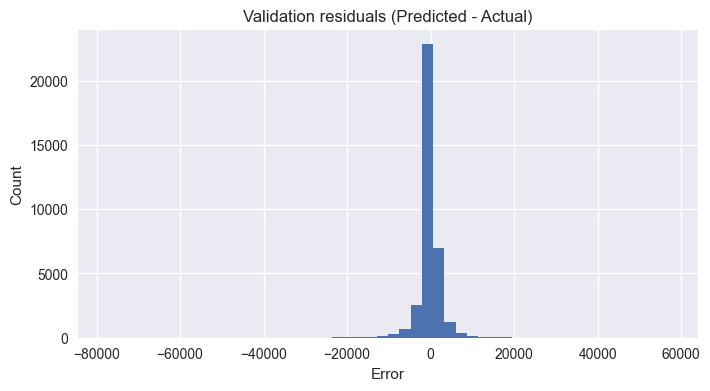

In [48]:
# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(val_df["Error"], bins=50)
plt.title("Validation residuals (Predicted - Actual)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()


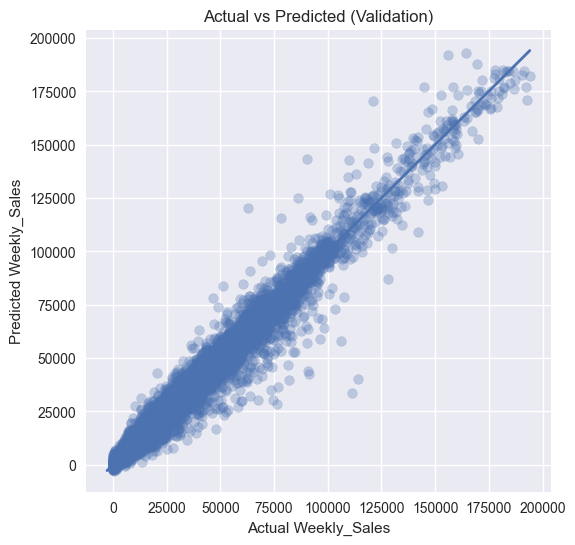

In [49]:
# Actual vs Predicted scatter
plt.figure(figsize=(6, 6))
plt.scatter(val_df["Actual"], val_df["Predicted"], alpha=0.3)
min_val = min(val_df["Actual"].min(), val_df["Predicted"].min())
max_val = max(val_df["Actual"].max(), val_df["Predicted"].max())
plt.plot([min_val, max_val], [min_val, max_val], linewidth=2)
plt.xlabel("Actual Weekly_Sales")
plt.ylabel("Predicted Weekly_Sales")
plt.title("Actual vs Predicted (Validation)")
plt.show()


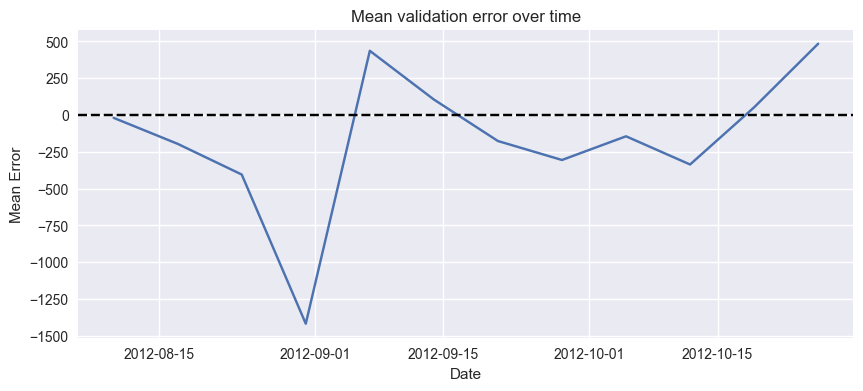

In [50]:
# Mean error over time (average per Date)
weekly_error = val_df.groupby("Date")["Error"].mean()
plt.figure(figsize=(10, 4))
plt.plot(weekly_error.index, weekly_error.values)
plt.axhline(0, linestyle="--", color="black")
plt.xlabel("Date")
plt.ylabel("Mean Error")
plt.title("Mean validation error over time")
plt.show()

##  Segmented Error Analysis (Store, Dept, Month, Holiday)

Now we check **where** the model performs well or poorly:

- By **Store**
- By **Dept**
- By **Year‑Month**
- By **Holiday vs Non‑holiday** (if holiday flag exists)

This is very important in a real project because some segments may need special treatment or additional features.


In [51]:
def group_metrics(df, group_cols):
    """Compute metrics for each group defined by group_cols."""
    rows = []
    for keys, grp in df.groupby(group_cols):
        m = regression_metrics(grp["Actual"].values, grp["Predicted"].values)
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(m)
        rows.append(row)
    return pd.DataFrame(rows)


In [52]:
# Add Year, Month for grouping
val_df["Year"]  = val_df["Date"].dt.year
val_df["Month"] = val_df["Date"].dt.month


In [53]:
# Detect holiday column if present
holiday_col = None
for c in ["IsHoliday", "IsHoliday_x", "IsHoliday_y"]:
    if c in val_df.columns:
        holiday_col = c
        break

if holiday_col is not None:
    val_df["IsHolidayFlag"] = val_df[holiday_col].astype(int)
else:
    val_df["IsHolidayFlag"] = 0  # fallback: no holiday info


In [54]:
#  Metrics by Store
store_metrics = group_metrics(val_df, ["Store"]).sort_values("RMSE")
print("\nPer-Store validation metrics (top 10 by RMSE):")
print(store_metrics.head(10))



Per-Store validation metrics (top 10 by RMSE):
    Store         RMSE         MAE          MAPE       WAPE
29     30  1016.103078  489.846669  3.757117e+03   5.576675
36     37  1169.018659  575.363150  1.404475e+02   5.701726
35     36  1255.059028  644.045683  9.992771e+01   9.688613
4       5  1301.035562  620.536784  5.689710e+03  11.974703
32     33  1309.026558  606.877409  2.088350e+02  10.562271
43     44  1383.178899  532.997138  1.329279e+02   8.198443
41     42  1417.255869  672.609422  1.358772e+07   6.070686
42     43  1513.403256  757.849207  2.175902e+02   5.833974
2       3  1539.469519  792.528635  4.530019e+07  12.212916
37     38  1655.989324  643.638460  2.497758e+02   8.048539


In [55]:
#  Metrics by Dept
dept_metrics = group_metrics(val_df, ["Dept"]).sort_values("RMSE")
print("\nPer-Dept validation metrics (top 10 by RMSE):")
print(dept_metrics.head(10))



Per-Dept validation metrics (top 10 by RMSE):
    Dept        RMSE         MAE          MAPE         WAPE
37    39  118.620635   93.310471  9.669357e+02   500.995806
42    45  122.162084   90.788087  7.335455e+02   388.801834
50    54  168.745418  129.793948  8.061693e+07   352.455132
55    60  184.425899  142.175003  7.390856e+01    46.196432
44    47  238.862835  188.009847  3.206416e+08   166.311135
54    59  243.015929  176.107385  2.286899e+02    84.304774
48    51  273.370939  234.980477  5.871904e+03  3559.111841
77    99  284.807227  183.884644  1.174014e+05   168.693042
26    28  331.607486  233.955202  1.749044e+02    44.349699
49    52  383.340449  282.353993  1.540447e+02    16.244286


In [56]:
#  Metrics by Year-Month
month_metrics = group_metrics(val_df, ["Year", "Month"]).sort_values(["Year", "Month"])
print("\nPer Year-Month validation metrics:")
print(month_metrics)



Per Year-Month validation metrics:
   Year  Month         RMSE          MAE          MAPE      WAPE
0  2012      8  3095.288458  1538.771663  5.584981e+06  9.573015
1  2012      9  3035.313001  1477.256309  1.012029e+03  9.653596
2  2012     10  2999.412761  1438.536490  6.940094e+05  9.229886


In [57]:
#  Holiday vs Non-holiday
holiday_metrics = group_metrics(val_df, ["IsHolidayFlag"]).sort_values("IsHolidayFlag")
holiday_metrics["IsHolidayFlag"] = holiday_metrics["IsHolidayFlag"].map({0: "Non-holiday", 1: "Holiday"})
print("\nHoliday vs Non-holiday metrics:")
print(holiday_metrics)


Holiday vs Non-holiday metrics:
  IsHolidayFlag         RMSE          MAE          MAPE       WAPE
0   Non-holiday  2948.766377  1455.265352  2.279944e+06   9.335527
1       Holiday  3937.983302  1809.433842  1.428376e+03  11.051939


##  Time‑Series Cross‑Validation (Backtesting)

To check **robustness** over time, we use **TimeSeriesSplit**:

- The data is split into multiple folds that respect time order
- For each fold, we train on past data and validate on future data
- We collect metrics for each fold and then compute mean ± std

If performance is stable across folds, we have more confidence in the model.


In [60]:
# 
#  ENCODE CATEGORICALS SAFELY

X = X.copy()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].astype("category").cat.codes

# Full numpy arrays
X_full = X.values
y_full = y.values


#  TIME SERIES CV SETUP

tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)

cv_results = []
fold_idx = 1


#  CROSS-VALIDATION LOOP

for train_idx, val_idx in tscv.split(X_full):
    X_tr, X_va = X_full[train_idx], X_full[val_idx]
    y_tr, y_va = y_full[train_idx], y_full[val_idx]

    dtr = lgb.Dataset(X_tr, label=y_tr)
    dva = lgb.Dataset(X_va, label=y_va)

    model = lgb.train(
        best_params,
        dtr,
        valid_sets=[dva],
        num_boost_round=2000
    )

    preds = model.predict(X_va, num_iteration=model.best_iteration)

    # Compute metrics (RMSE, MAE, MAPE, etc.)
    m = regression_metrics(y_va, preds)
    m["fold"] = fold_idx
    m["best_iteration"] = model.best_iteration
    cv_results.append(m)

    print(f"\nFold {fold_idx} metrics:")
    print_metrics("  ", m)

    fold_idx += 1


#  COLLECT RESULTS

cv_df = pd.DataFrame(cv_results)

print("\nTime-series CV results (each fold):")
print(cv_df)

print("\nCV mean ± std:")
for metric in ["RMSE", "MAE", "MAPE", "WAPE", "best_iteration"]:
    mean_val = cv_df[metric].mean()
    std_val  = cv_df[metric].std()
    print(f"  {metric}: {mean_val:.4f} ± {std_val:.4f}")



Fold 1 metrics:
  
  RMSE: 9148.6215
  MAE: 2978.0271
  MAPE: 1536529.8916
  WAPE: 18.2338
  fold: 1.0000
  best_iteration: 0.0000

Fold 2 metrics:
  
  RMSE: 4349.9730
  MAE: 1869.6620
  MAPE: 1975190.3796
  WAPE: 11.4513
  fold: 2.0000
  best_iteration: 0.0000

Fold 3 metrics:
  
  RMSE: 3394.2867
  MAE: 1615.4754
  MAPE: 2198650.4064
  WAPE: 10.1593
  fold: 3.0000
  best_iteration: 0.0000

Time-series CV results (each fold):
          RMSE          MAE          MAPE       WAPE  fold  best_iteration
0  9148.621503  2978.027095  1.536530e+06  18.233827     1               0
1  4349.973025  1869.662041  1.975190e+06  11.451298     2               0
2  3394.286738  1615.475411  2.198650e+06  10.159335     3               0

CV mean ± std:
  RMSE: 5630.9604 ± 3083.6324
  MAE: 2154.3882 ± 724.5264
  MAPE: 1903456.8925 ± 336838.4834
  WAPE: 13.2815 ± 4.3372
  best_iteration: 0.0000 ± 0.0000


##  Feature Importance & Optional Pruning

We now look at **which features are most important** according to LightGBM.

Steps:

1. Train a model on **all training rows** once (for importance only)
2. Get feature importance scores
3. Show the top 20 features as a table and bar chart

You can later decide to **remove very low‑importance features** and retrain to simplify the model.


In [63]:
# Train a model on all df_model once (for importance only)
dtrain_full_tmp = lgb.Dataset(X, label=y)

num_rounds = gbm_model.best_iteration
if num_rounds is None or num_rounds == 0:
    num_rounds = 2000   # fallback to full boosting

model_tmp = lgb.train(
    best_params,
    dtrain_full_tmp,
    num_boost_round=num_rounds
)

importances = model_tmp.feature_importance()
feat_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": importances,
}).sort_values("importance", ascending=False)

print("\nTop 20 features by importance:")
print(feat_imp_df.head(20))



Top 20 features by importance:
         feature  importance
28      hist_std        3232
23   roll_mean_7        2370
15          Week        2112
20         lag_7        1775
21        lag_14        1773
1    Temperature        1680
22        lag_28        1573
17           Day        1563
26     hist_mean        1361
27   hist_median        1296
24  roll_mean_14        1261
2     Fuel_Price        1233
8            CPI        1208
25  roll_mean_28        1129
9   Unemployment        1052
12          Size        1023
5      MarkDown3         790
14         Month         733
3      MarkDown1         590
4      MarkDown2         583


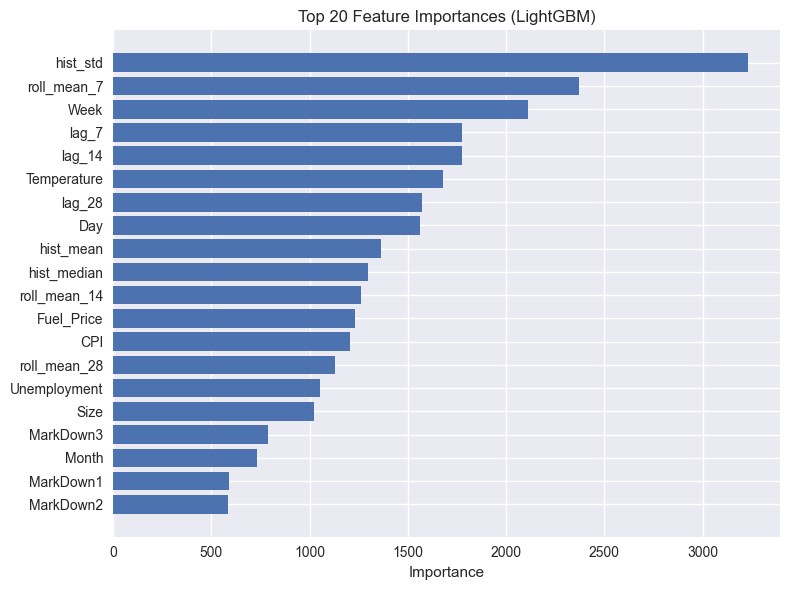

In [64]:
# Plot top 20 feature importances
top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(
    feat_imp_df["feature"].head(top_n)[::-1],
    feat_imp_df["importance"].head(top_n)[::-1],
)
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (LightGBM)")
plt.tight_layout()
plt.show()

##  Train Final Model on Full Training Data & Create Submission

Finally, we:

1. Train a LightGBM model on **all available training rows** (df_model)
2. Save the trained model to disk
3. Prepare feature matrix for **test set**
4. Predict Weekly_Sales for the test data
5. Save predictions into outputs/submission.csv



In [66]:
# Final model on all df_model rows (X, y)
dtrain_full = lgb.Dataset(X, label=y)

# Best iteration fallback
num_rounds = gbm_model.best_iteration
if num_rounds is None or num_rounds == 0:
    num_rounds = 2000

final_model = lgb.train(
    best_params,
    dtrain_full,
    num_boost_round=num_rounds
)

model_path = OUT_DIR / "final_lightgbm_model.joblib"
joblib.dump(final_model, model_path)

print("Final model saved to:", model_path)


Final model saved to: outputs\final_lightgbm_model.joblib


In [67]:
# Prepare test features (same columns and order)
test_fe_sorted = test_fe.sort_values("Date").reset_index(drop=True)
X_test = test_fe_sorted[feature_cols].copy()

print("X_test shape:", X_test.shape)


X_test shape: (115064, 29)


In [69]:

#  FIX TEST DATA ENCODING (CRUCIAL)

X_test = X_test.copy()

for col in X_test.columns:
    if X_test[col].dtype == "object":
        X_test[col] = X_test[col].astype("category").cat.codes



#  PREDICT USING FINAL TRAINED MODEL

# Always use full boosting or best iteration fallback
num_rounds = final_model.best_iteration if final_model.best_iteration and final_model.best_iteration > 0 else 2000

test_preds = final_model.predict(X_test, num_iteration=num_rounds)



#  BUILD SUBMISSION DATAFRAME

submission = test_fe_sorted[["Store", "Dept", "Date"]].copy()
submission["Weekly_Sales"] = test_preds



#  SAVE SUBMISSION TO CSV

sub_path = OUT_DIR / "submission.csv"
submission.to_csv(sub_path, index=False)

print("Submission saved to:", sub_path)

# Show preview
submission.head()


Submission saved to: outputs\submission.csv


,Store,Dept,Date,Weekly_Sales
0,1,1,2012-11-02,24145.502437
1,19,10,2012-11-02,29326.678890
2,16,55,2012-11-02,4902.729864
3,22,18,2012-11-02,23526.077248
4,25,16,2012-11-02,2150.934835


##  Summary

In this notebook we:

1. Loaded and cleaned the Walmart weekly sales data  
2. Engineered powerful time‑series features (lags, rolling means, historical stats)  
3. Built a strong baseline using lag_7  
4. Trained and tuned a **LightGBM** model with Optuna  
5. Evaluated performance on a realistic time‑based validation set  
6. Did detailed **error and residual analysis**  
7. Used **time‑series cross‑validation** to check robustness  
8. Examined **feature importance**  
9. Trained a final model on all training data and created `submission.csv`

You can further extend this project by:

- Adding more domain‑specific features (promotions, events, etc.)  
- Trying alternative models (XGBoost, CatBoost, deep learning)  
- Building a report / presentation using the results from this notebook  
